In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import math
sns.set(style='whitegrid')

In [2]:
if True:
        widths = [512]
        num_exps = [16, 8, 4, 2]
        lrs = [0.064, 0.032, 0.016, 0.008, 0.004,]
        seeds = [1]
        n_layer = 10
seeds = [1]
depth = 10

time = '20250906_054743'

In [3]:
results_val = {}
results_tr = {}
for lr in lrs:
    for width in widths:
        for num_exp in num_exps:
            num_act = int(num_exp / 2)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}/log.csv'
                if os.path.exists(file_name):
                    csv_df = pd.read_csv(file_name)
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_cccc/out_20250906_054743/width512_depth10_experts16_active8_seed1_lr0.064/log.csv, val_loss achieved 7.721019268035889
average training loss for last 50 steps: 7.710108051300049

result found for ../run_data/mutransfer_lr_cccc/out_20250906_054743/width512_depth10_experts8_active4_seed1_lr0.064/log.csv, val_loss achieved 7.795768737792969
average training loss for last 50 steps: 7.715269708633423

result found for ../run_data/mutransfer_lr_cccc/out_20250906_054743/width512_depth10_experts4_active2_seed1_lr0.064/log.csv, val_loss achieved 7.719422340393066
average training loss for last 50 steps: 7.589150295257569

result found for ../run_data/mutransfer_lr_cccc/out_20250906_054743/width512_depth10_experts2_active1_seed1_lr0.064/log.csv, val_loss achieved 7.668033599853516
average training loss for last 50 steps: 7.657836046218872

result found for ../run_data/mutransfer_lr_cccc/out_20250906_054743/width512_depth10_experts16_active8_seed1_lr0.0

In [4]:
def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    
    # Average over seeds for each configuration and lr
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        
        # Average MSEs for each lr
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    
    # Count total experiments
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    
    # Print summary
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    
    # Plot each configuration
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                num_act = int(n_exp / 2)
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('Test MSE', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results

Total experiments: 20

Results by configuration:
  n=2, width=512: 5 valid lr points
    Best: lr=8.000e-03, MSE=4.815037
  n=4, width=512: 5 valid lr points
    Best: lr=3.200e-02, MSE=4.887006
  n=8, width=512: 5 valid lr points
    Best: lr=8.000e-03, MSE=4.830678
  n=16, width=512: 5 valid lr points
    Best: lr=8.000e-03, MSE=4.704204



Plot saved as: plots/hp_transfer_plot_20250906_150408.png


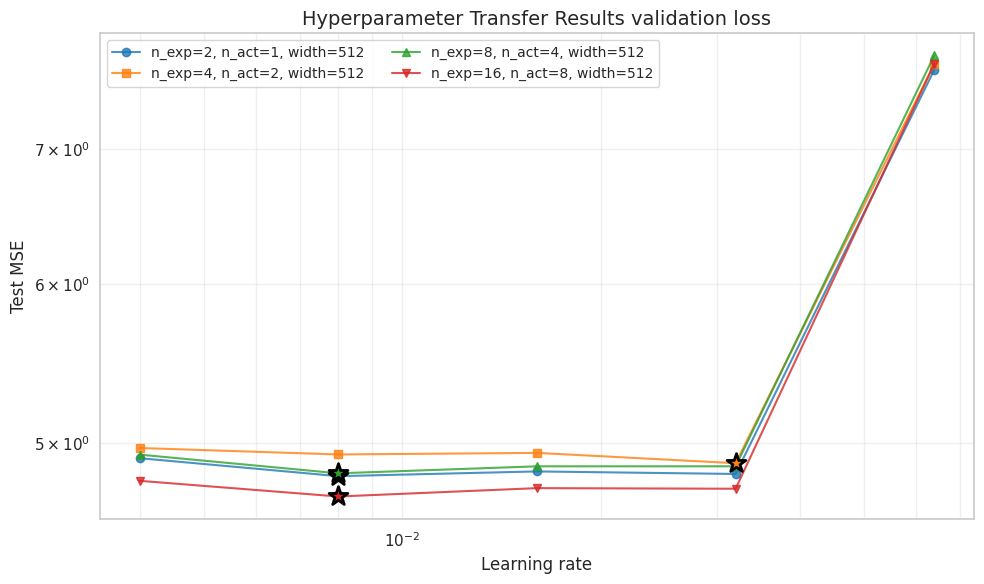

{(16, 512): [(0.004, np.float64(4.789348602294922)),
  (0.008, np.float64(4.704203605651856)),
  (0.016, np.float64(4.749411582946777)),
  (0.032, np.float64(4.74614143371582)),
  (0.064, np.float64(7.721019268035889))],
 (8, 512): [(0.004, np.float64(4.935183525085449)),
  (0.008, np.float64(4.83067798614502)),
  (0.016, np.float64(4.869588375091553)),
  (0.032, np.float64(4.86974573135376)),
  (0.064, np.float64(7.795768737792969))],
 (4, 512): [(0.004, np.float64(4.9727559089660645)),
  (0.008, np.float64(4.936223030090332)),
  (0.016, np.float64(4.945054054260254)),
  (0.032, np.float64(4.8870062828063965)),
  (0.064, np.float64(7.719422340393066))],
 (2, 512): [(0.004, np.float64(4.915098190307617)),
  (0.008, np.float64(4.815036773681641)),
  (0.016, np.float64(4.841208457946777)),
  (0.032, np.float64(4.827147483825684)),
  (0.064, np.float64(7.668033599853516))]}

In [5]:
plot_results(results_val, title = "validation loss")

Total experiments: 20

Results by configuration:
  n=2, width=512: 5 valid lr points
    Best: lr=8.000e-03, MSE=4.750796
  n=4, width=512: 5 valid lr points
    Best: lr=3.200e-02, MSE=4.749965
  n=8, width=512: 5 valid lr points
    Best: lr=8.000e-03, MSE=4.745365
  n=16, width=512: 5 valid lr points
    Best: lr=8.000e-03, MSE=4.758038

Plot saved as: plots/hp_transfer_plot_20250906_150426.png


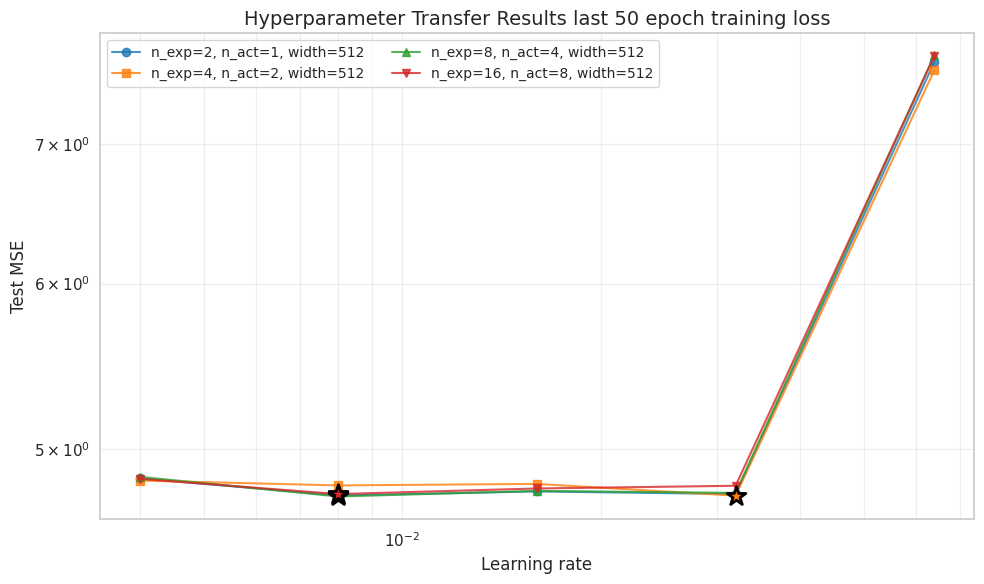

{(16, 512): [(0.004, np.float64(4.8385677242279055)),
  (0.008, np.float64(4.758038330078125)),
  (0.016, np.float64(4.787494754791259)),
  (0.032, np.float64(4.801802129745483)),
  (0.064, np.float64(7.710108051300049))],
 (8, 512): [(0.004, np.float64(4.849327201843262)),
  (0.008, np.float64(4.745365247726441)),
  (0.016, np.float64(4.774771356582642)),
  (0.032, np.float64(4.764086923599243)),
  (0.064, np.float64(7.715269708633423))],
 (4, 512): [(0.004, np.float64(4.829355964660644)),
  (0.008, np.float64(4.8036947917938235)),
  (0.016, np.float64(4.81170841217041)),
  (0.032, np.float64(4.749965238571167)),
  (0.064, np.float64(7.589150295257569))],
 (2, 512): [(0.004, np.float64(4.841489944458008)),
  (0.008, np.float64(4.750796175003051)),
  (0.016, np.float64(4.771892614364624)),
  (0.032, np.float64(4.75828501701355)),
  (0.064, np.float64(7.657836046218872))]}

In [6]:
plot_results(results_tr, title = "last 50 epoch training loss")